In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Imports Needed

In [ ]:
import pandas as pdobesty
from sklearn.ensemble import AdaBoostClassifier as ada_obsty
from sklearn.ensemble import RandomForestClassifier as rfc_obsty
from sklearn.metrics import classification_report as obstyclrp
from sklearn.metrics import confusion_matrix as obscm
import matplotlib.pyplot as pltobsty
import seaborn as snsobsty
from sklearn.metrics import roc_auc_score as obsauc
from sklearn.metrics import roc_curve as obsroc
from sklearn.model_selection import GridSearchCV as obsgscv
import time as obstme
from imblearn.over_sampling import SMOTE as obssmmt
from collections import Counter as obcc
from sklearn.preprocessing import LabelBinarizer as lbbobb
from sklearn.model_selection import train_test_split as ttobsp
import numpy as obnp
import warnings as warnobsty
warnobsty.filterwarnings("ignore")

In [ ]:
dfobesty = pdobesty.read_csv('/content/drive/MyDrive/TrainingProjects/JANProject/cccvvv/obesity_final.csv')
dfobesty

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,0,21.000000,1.620000,64.000000,1,0,2.0,3.0,2,0,2.000000,0,0.000000,1.000000,3,3,1
1,0,21.000000,1.520000,56.000000,1,0,3.0,3.0,2,1,3.000000,1,3.000000,0.000000,2,3,1
2,1,23.000000,1.800000,77.000000,1,0,2.0,3.0,2,0,2.000000,0,2.000000,1.000000,1,3,1
3,1,27.000000,1.800000,87.000000,0,0,3.0,3.0,2,0,2.000000,0,2.000000,0.000000,1,4,5
4,1,22.000000,1.780000,89.800000,0,0,2.0,1.0,2,0,2.000000,0,0.000000,0.000000,2,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,0,20.976842,1.710730,131.408528,1,1,3.0,3.0,2,0,1.728139,0,1.676269,0.906247,2,3,4
2083,0,21.982942,1.748584,133.742943,1,1,3.0,3.0,2,0,2.005130,0,1.341390,0.599270,2,3,4
2084,0,22.524036,1.752206,133.689352,1,1,3.0,3.0,2,0,2.054193,0,1.414209,0.646288,2,3,4
2085,0,24.361936,1.739450,133.346641,1,1,3.0,3.0,2,0,2.852339,0,1.139107,0.586035,2,3,4


Multi-class

In [ ]:
dfobesty['Obesity'].value_counts()

,count
Obesity,
2,351
4,324
3,297
6,290
1,282
5,276
0,267


In [ ]:
OBX = dfobesty.drop('Obesity', axis=1)
OBy = dfobesty['Obesity']

**SMOTE - oversampling**

In [ ]:
#******Train=60%, Val=20%, Test=20%**********
ObXtra, ObXtem, Obytra, Obytem = ttobsp(OBX, OBy, test_size=0.4, random_state=2)
ObXval, ObXtes, Obyval, Obytes = ttobsp(ObXtem, Obytem, test_size=0.5, random_state=2)

smtmk_ccd = obssmmt()
ObXtra_resam, Obytra_resam = smtmk_ccd.fit_resample(ObXtra, Obytra)

print("Multi-class distribution-Before:", obcc(Obytra))
print("Multi-class distribution-After:", obcc(Obytra_resam))

Multi-class distribution-Before: Counter({2: 212, 4: 188, 6: 185, 3: 175, 5: 173, 1: 161, 0: 158})
Multi-class distribution-After: Counter({6: 212, 1: 212, 4: 212, 3: 212, 0: 212, 5: 212, 2: 212})


**Boosting** - *AdaBoost(AB)*

In [ ]:
ADAml = ada_obsty()

confi_osty = {
    'n_estimators': [10, 20, 30],
    'algorithm': ['SAMME', 'SAMME.R'],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
}

gsobbml = obsgscv(estimator=ADAml, param_grid=confi_osty, scoring='accuracy', cv=2, verbose=1)
gsobbml.fit(ObXtra_resam, Obytra_resam)
obstart = obstme.time()
obend = obstme.time()
Tra_tm = obend - obstart
ADAmlBst = gsobbml.best_estimator_
TrainOb = ADAmlBst.score(ObXtra_resam, Obytra_resam)

ValOb_pre = ADAmlBst.predict(ObXval)
sob_val = obstme.time()
eob_val = obstme.time()
Val_tim = eob_val - sob_val
Valobauc = obsauc(Obyval, ADAmlBst.predict_proba(ObXval), multi_class='ovr')

TestOb_pre = ADAmlBst.predict(ObXtes)
sob_tst = obstme.time()
eob_tst = obstme.time()
Tst_tim = eob_tst - sob_tst
Tstobauc = obsauc(Obytes, ADAmlBst.predict_proba(ObXtes), multi_class='ovr')

print("\noptimal configurations of AB:")
print(gsobbml.best_params_)
print(f"\ntraining duration: {Tra_tm} seconds")
print(f"train accuracy: {TrainOb}")
print(f"validation duration: {Val_tim:.4f} seconds")
print(obstyclrp(Obyval, ValOb_pre))
print(f"\nAUC validation: {Valobauc}")
print(f"testing duration: {Tst_tim:.4f} seconds")
print(obstyclrp(Obytes, TestOb_pre))
print(f"\nAUC testing: {Tstobauc}")

Fitting 2 folds for each of 24 candidates, totalling 48 fits

optimal configurations of AB:
{'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 30}

training duration: 3.6716461181640625e-05 seconds
train accuracy: 0.4555256064690027
validation duration: 0.0001 seconds
              precision    recall  f1-score   support

           0       0.67      0.98      0.80        63
           1       0.58      0.17      0.26        65
           2       1.00      0.07      0.12        60
           3       0.40      0.06      0.11        63
           4       0.45      0.97      0.61        63
           5       0.00      0.00      0.00        50
           6       0.33      0.96      0.49        53

    accuracy                           0.46       417
   macro avg       0.49      0.46      0.34       417
weighted avg       0.51      0.46      0.35       417


AUC validation: 0.8746696686673688
testing duration: 0.0000 seconds
              precision    recall  f1-score   support



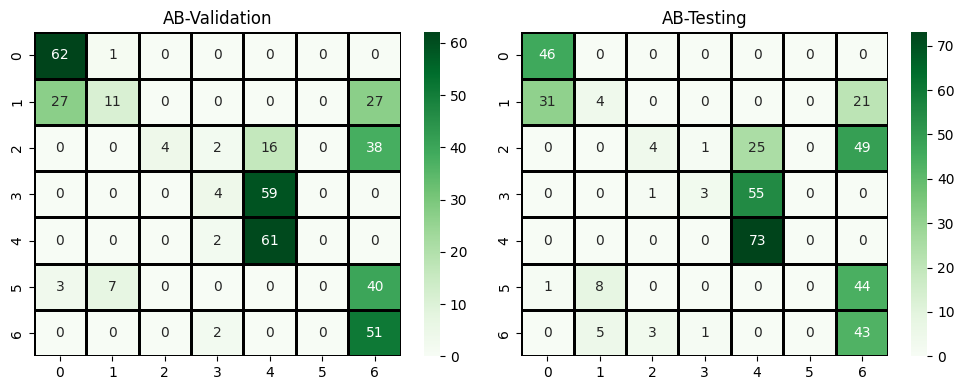

In [ ]:
bccmval = obscm(Obyval, ValOb_pre)
bccmtst = obscm(Obytes, TestOb_pre)

figob, axesob = pltobsty.subplots(1, 2, figsize=(10, 4))
snsobsty.heatmap(bccmval, annot=True, fmt="d", cmap="Greens", linewidths=1, linecolor='black', ax=axesob[0])
axesob[0].set_title("AB-Validation")
snsobsty.heatmap(bccmtst, annot=True, fmt="d", cmap="Greens", linewidths=1, linecolor='black', ax=axesob[1])
axesob[1].set_title("AB-Testing")

pltobsty.tight_layout()
pltobsty.show()

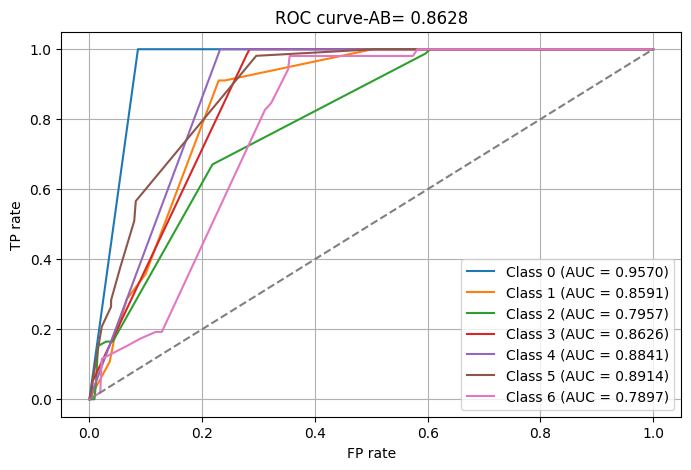

In [ ]:
#****************ROC curve*******************
Tst_prob = ADAmlBst.predict_proba(ObXtes)
lboblb = lbbobb()
Obytes_bin = lboblb.fit_transform(Obytes)

pltobsty.figure(figsize=(8, 5))
AUCtst_scors = obsauc(Obytes_bin, Tst_prob, multi_class='ovr', average=None)
AUCob_avg = obnp.mean(AUCtst_scors)
num_classes = Obytes_bin.shape[1]
for i in range(num_classes):
    fpr, tpr, _ = obsroc(Obytes_bin[:, i], Tst_prob[:, i])
    pltobsty.plot(fpr, tpr, label=f'Class {i} (AUC = {AUCtst_scors[i]:.4f})')

pltobsty.plot([0, 1], [0, 1], linestyle='--', color='gray')
pltobsty.xlabel('FP rate')
pltobsty.ylabel('TP rate')
pltobsty.title(f'ROC curve-AB= {AUCob_avg:.4f}')
pltobsty.legend(loc='lower right')
pltobsty.grid()
pltobsty.show()

**Bagging** - *Random Forest Classifier(RF)*

In [ ]:
RFCml = rfc_obsty()

confi_osty = {
    'n_estimators': [10, 20, 30],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'min_samples_split': [2, 5, 7, 10],
}

gsobbml = obsgscv(estimator=RFCml, param_grid=confi_osty, scoring='accuracy', cv=2, verbose=1)
gsobbml.fit(ObXtra_resam, Obytra_resam)
obstart = obstme.time()
obend = obstme.time()
Tra_tm = obend - obstart
RFCmlBst = gsobbml.best_estimator_
TrainOb = RFCmlBst.score(ObXtra_resam, Obytra_resam)

ValOb_pre = RFCmlBst.predict(ObXval)
sob_val = obstme.time()
eob_val = obstme.time()
Val_tim = eob_val - sob_val
Valobauc = obsauc(Obyval, RFCmlBst.predict_proba(ObXval), multi_class='ovr')

TestOb_pre = RFCmlBst.predict(ObXtes)
sob_tst = obstme.time()
eob_tst = obstme.time()
Tst_tim = eob_tst - sob_tst
Tstobauc = obsauc(Obytes, RFCmlBst.predict_proba(ObXtes), multi_class='ovr')

print("\noptimal configurations of RF:")
print(gsobbml.best_params_)
print(f"\ntraining duration: {Tra_tm} seconds")
print(f"train accuracy: {TrainOb}")
print(f"validation duration: {Val_tim:.4f} seconds")
print(obstyclrp(Obyval, ValOb_pre))
print(f"\nAUC validation: {Valobauc}")
print(f"testing duration: {Tst_tim:.4f} seconds")
print(obstyclrp(Obytes, TestOb_pre))
print(f"\nAUC testing: {Tstobauc}")

Fitting 2 folds for each of 36 candidates, totalling 72 fits

optimal configurations of RF:
{'criterion': 'entropy', 'min_samples_split': 2, 'n_estimators': 20}

training duration: 3.7670135498046875e-05 seconds
train accuracy: 1.0
validation duration: 0.0000 seconds
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.85      0.97      0.91        65
           2       1.00      0.98      0.99        60
           3       0.98      0.98      0.98        63
           4       0.98      1.00      0.99        63
           5       0.96      0.88      0.92        50
           6       0.96      0.92      0.94        53

    accuracy                           0.96       417
   macro avg       0.96      0.95      0.96       417
weighted avg       0.96      0.96      0.96       417


AUC validation: 0.995176657090399
testing duration: 0.0000 seconds
              precision    recall  f1-score   support

           0

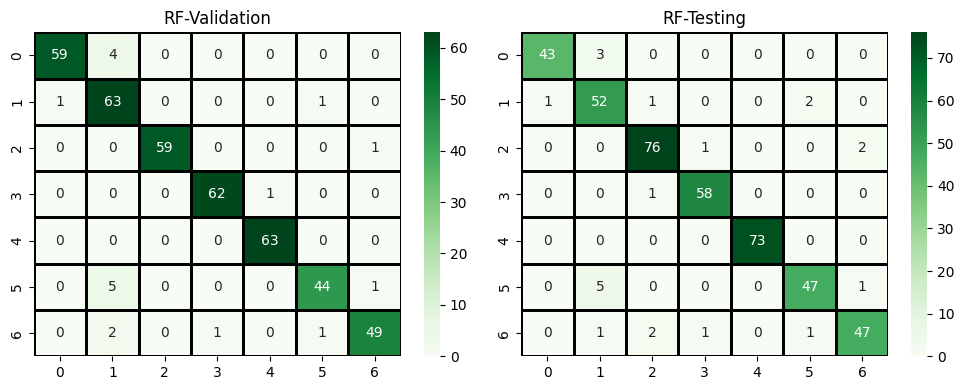

In [ ]:
bccmval = obscm(Obyval, ValOb_pre)
bccmtst = obscm(Obytes, TestOb_pre)

figob, axesob = pltobsty.subplots(1, 2, figsize=(10, 4))
snsobsty.heatmap(bccmval, annot=True, fmt="d", cmap="Greens", linewidths=1, linecolor='black', ax=axesob[0])
axesob[0].set_title("RF-Validation")
snsobsty.heatmap(bccmtst, annot=True, fmt="d", cmap="Greens", linewidths=1, linecolor='black', ax=axesob[1])
axesob[1].set_title("RF-Testing")

pltobsty.tight_layout()
pltobsty.show()

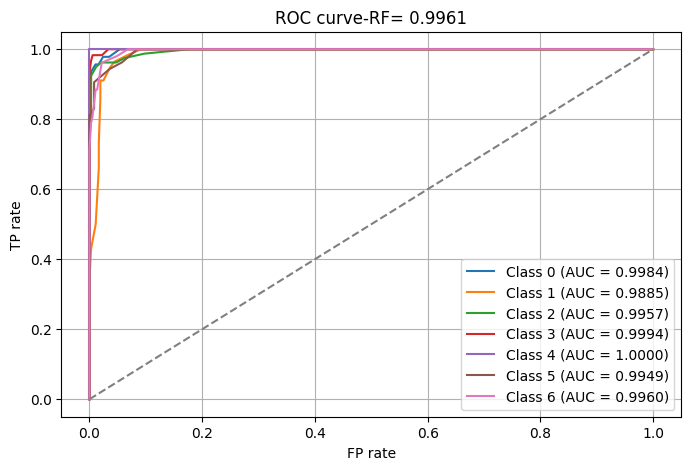

In [ ]:
#****************ROC curve*******************
Tst_prob = RFCmlBst.predict_proba(ObXtes)
lboblb = lbbobb()
Obytes_bin = lboblb.fit_transform(Obytes)

pltobsty.figure(figsize=(8, 5))
AUCtst_scors = obsauc(Obytes_bin, Tst_prob, multi_class='ovr', average=None)
AUCob_avg = obnp.mean(AUCtst_scors)
num_classes = Obytes_bin.shape[1]
for i in range(num_classes):
    fpr, tpr, _ = obsroc(Obytes_bin[:, i], Tst_prob[:, i])
    pltobsty.plot(fpr, tpr, label=f'Class {i} (AUC = {AUCtst_scors[i]:.4f})')

pltobsty.plot([0, 1], [0, 1], linestyle='--', color='gray')
pltobsty.xlabel('FP rate')
pltobsty.ylabel('TP rate')
pltobsty.title(f'ROC curve-RF= {AUCob_avg:.4f}')
pltobsty.legend(loc='lower right')
pltobsty.grid()
pltobsty.show()